In [2]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as datetime
sales = pd.read_csv('/content/drive/MyDrive/MSSP607/InternetSales.csv', encoding='latin-1')

Mounted at /content/drive


/tmp/ipython-input-3983176902.py:8: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv('/content/drive/MyDrive/MSSP607/InternetSales.csv', encoding='latin-1')


Use Google Colabs and Python to create an Internet Sales forecast for the next five years.

In [3]:
# group ts by quarter
sales['OrderDateKey'] = pd.to_datetime(sales['OrderDateKey'], format='%Y%m%d')
ts_quarter = sales.groupby(pd.Grouper(key='OrderDateKey', freq='QE'))['SalesAmount'].sum().reset_index()
ts_quarter = ts_quarter.set_index('OrderDateKey')

In [4]:
#forecast future internet sales by quarter
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(ts_quarter['SalesAmount'], order=(1, 1, 1))
model_fit = model.fit()
forecast = model_fit.forecast(steps=10)
forecast
#forecast date index
forecast_index = pd.date_range(start=ts_quarter.index[-1] + pd.offsets.QuarterEnd(), periods=10, freq='Q')
forecast_index
forecast.index = forecast_index

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA paramete

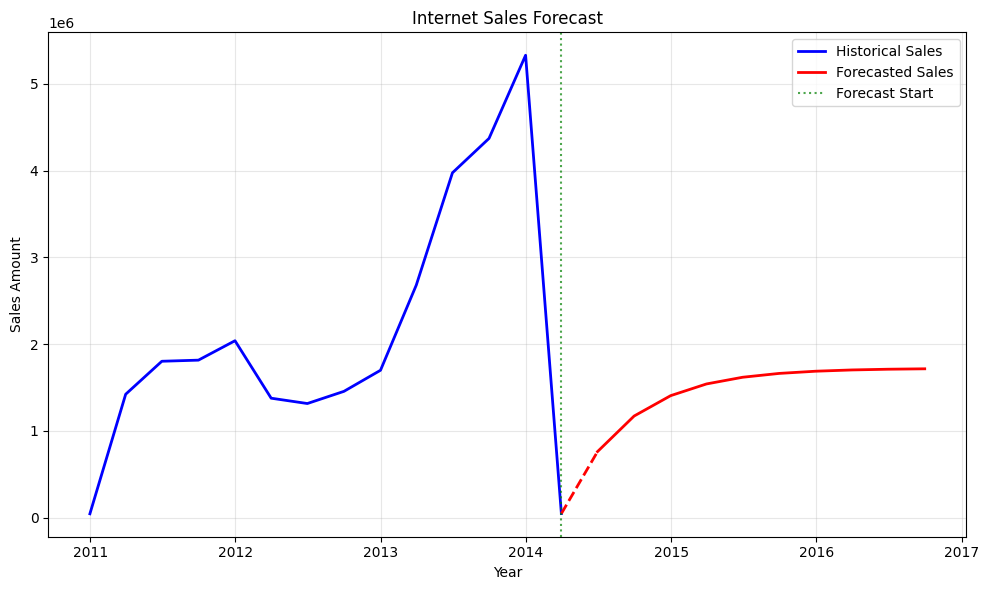

In [8]:
plt.figure(figsize = (10,6))
ts_quarter_reset = ts_quarter.reset_index()
forecast_df = forecast.reset_index()
forecast_df.columns = ['OrderDateKey', 'SalesAmount']
full_timeline = pd.concat([
    ts_quarter_reset[['OrderDateKey', 'SalesAmount']],
    forecast_df.rename(columns={'predicted_mean': 'SalesAmount'})
], ignore_index=True)
plt.plot(ts_quarter_reset['OrderDateKey'],
         ts_quarter_reset['SalesAmount'],
         color='blue',
         linewidth=2,
         label='Historical Sales')
plt.plot(forecast_df['OrderDateKey'],
         forecast_df['SalesAmount'],
         color='red',
         linewidth=2,
         label='Forecasted Sales')

connection_x = [ts_quarter_reset['OrderDateKey'].iloc[-1], forecast_df['OrderDateKey'].iloc[0]]
connection_y = [ts_quarter_reset['SalesAmount'].iloc[-1], forecast_df['SalesAmount'].iloc[0]]
plt.plot(connection_x, connection_y, color='red', linestyle='--', linewidth=2)


last_historical_date = ts_quarter_reset['OrderDateKey'].iloc[-1]
plt.axvline(x=last_historical_date, color='green', linestyle=':',
            alpha=0.7, label='Forecast Start')

plt.title('Internet Sales Forecast')
plt.xlabel('Year')
plt.ylabel('Sales Amount')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# This cell is now redundant as the plotting code has been moved to the previous cell.
# It can be deleted.
print("历史数据信息:")
print(f"数据类型: {type(ts_quarter_reset['OrderDateKey'].iloc[0])}")
print(f"最后日期: {ts_quarter_reset['OrderDateKey'].iloc[-1]}")
print(f"最后值: {ts_quarter_reset['SalesAmount'].iloc[-1]}")

print("\n预测数据信息:")
print(f"数据类型: {type(forecast_index[0])}")
print(f"第一个日期: {forecast_index[0]}")
print(f"第一个值: {forecast.values[0]}")

print(f"\n时间间隔: {forecast_index[0] - ts_quarter_reset['OrderDateKey'].iloc[-1]}")

历史数据信息:
数据类型: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
最后日期: 2014-03-31 00:00:00
最后值: 45694.72

预测数据信息:
数据类型: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
第一个日期: 2014-06-30 00:00:00
第一个值: 760505.8347966196

时间间隔: 91 days 00:00:00


Using summary statistics, which product will generate the most sales?

In [12]:
import pandas as pd
product_sales = sales.groupby('ProductKey')['SalesAmount'].agg(['sum','mean','count','min','max','std']).round(2)
product_sales_sort = product_sales.sort_values('sum',ascending = False)
product_sales_sort

,sum,mean,count,min,max,std
ProductKey,,,,,,
312,1205876.99,3578.27,337,3578.27,3578.27,0.0
310,1202298.72,3578.27,336,3578.27,3578.27,0.0
313,1080637.54,3578.27,302,3578.27,3578.27,0.0
314,1055589.65,3578.27,295,3578.27,3578.27,0.0
311,1005493.87,3578.27,281,3578.27,3578.27,0.0
...,...,...,...,...,...,...
530,7425.12,4.99,1488,4.99,4.99,0.0
480,7307.39,2.29,3191,2.29,2.29,0.0
484,7218.60,7.95,908,7.95,7.95,0.0


In [14]:
#top sales product
top_product = product_sales_sort.index[0]
top_product

np.int64(312)